In [1]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn shap


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Instalação das bibliotecas necessárias
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn shap kagglehub
# Importando as bibliotecas
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    make_scorer
)

from sklearn.inspection import permutation_importance

# Configuração visual
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Pasta para salvar todas as imagens
PASTA_IMAGENS = Path("imagens_resultados")
PASTA_IMAGENS.mkdir(parents=True, exist_ok=True)


def salvar_figura(nome, dpi=300):
    """
    Salva a figura atual com um nome seguro.
    """

    nome_seguro = unicodedata.normalize("NFKD", nome)
    nome_seguro = nome_seguro.encode(
        "ascii",
        "ignore"
    ).decode("ascii")

    nome_seguro = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        nome_seguro
    ).strip("_").lower()

    caminho = PASTA_IMAGENS / f"{nome_seguro}.png"

    plt.savefig(
        caminho,
        dpi=dpi,
        bbox_inches="tight"
    )

    print(f"Imagem salva: {caminho}")

    return caminho


print("Bibliotecas importadas com sucesso.")
print(f"Pasta das imagens: {PASTA_IMAGENS.resolve()}")


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Bibliotecas importadas com sucesso.
Pasta das imagens: C:\IA Devs Especializacion\Fase 1\PROYECTO\FIAP_TechChallenge_01_2026\imagens_resultados


In [3]:
# Procurando o arquivo data.csv
caminhos_possiveis = [
    Path("data.csv"),
    Path("/app/data.csv"),
    Path("/content/data.csv")
]

caminho_arquivo = next(
    (
        caminho
        for caminho in caminhos_possiveis
        if caminho.exists()
    ),
    None
)

# Se o CSV não estiver no projeto, realizar o download
if caminho_arquivo is None:

    import kagglehub

    pasta_dataset = Path(
        kagglehub.dataset_download(
            "uciml/breast-cancer-wisconsin-data"
        )
    )

    arquivos_encontrados = list(
        pasta_dataset.rglob("data.csv")
    )

    if not arquivos_encontrados:
        raise FileNotFoundError(
            "O arquivo data.csv não foi encontrado."
        )

    caminho_arquivo = arquivos_encontrados[0]

# Carregando a base
dados = pd.read_csv(caminho_arquivo)

print("Base carregada com sucesso.")
print(f"Arquivo utilizado: {caminho_arquivo}")
print(f"Dimensões originais: {dados.shape}")

display(dados.head())

Base carregada com sucesso.
Arquivo utilizado: data.csv
Dimensões originais: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Informações gerais
print("INFORMAÇÕES DA BASE")
print("-------------------")

dados.info()

print("\nTipos das variáveis:")
display(
    pd.DataFrame({
        "coluna": dados.columns,
        "tipo": dados.dtypes.astype(str).values
    })
)

# Valores ausentes
valores_ausentes = pd.DataFrame({
    "quantidade_ausente": dados.isnull().sum(),
    "percentual_ausente": (
        dados.isnull().mean() * 100
    ).round(2)
})

print("\nColunas com valores ausentes:")
display(
    valores_ausentes[
        valores_ausentes["quantidade_ausente"] > 0
    ]
)

# Registros duplicados
quantidade_duplicados = dados.duplicated().sum()

print(
    f"Quantidade de registros duplicados: "
    f"{quantidade_duplicados}"
)

# Distribuição do diagnóstico
distribuicao_original = dados[
    "diagnosis"
].value_counts()

percentuais = (
    dados["diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

tabela_distribuicao = pd.DataFrame({
    "quantidade": distribuicao_original,
    "percentual": percentuais
})

print("\nDistribuição dos diagnósticos:")
display(tabela_distribuicao)

INFORMAÇÕES DA BASE
-------------------
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 1

,coluna,tipo
0,id,int64
1,diagnosis,str
2,radius_mean,float64
3,texture_mean,float64
4,perimeter_mean,float64
5,area_mean,float64
6,smoothness_mean,float64
7,compactness_mean,float64
8,concavity_mean,float64
9,concave points_mean,float64



Colunas com valores ausentes:


,quantidade_ausente,percentual_ausente
Unnamed: 32,569,100.0


Quantidade de registros duplicados: 0

Distribuição dos diagnósticos:


,quantidade,percentual
diagnosis,,
B,357,62.74
M,212,37.26


Imagem salva: imagens_resultados\01_distribuicao_diagnosticos.png


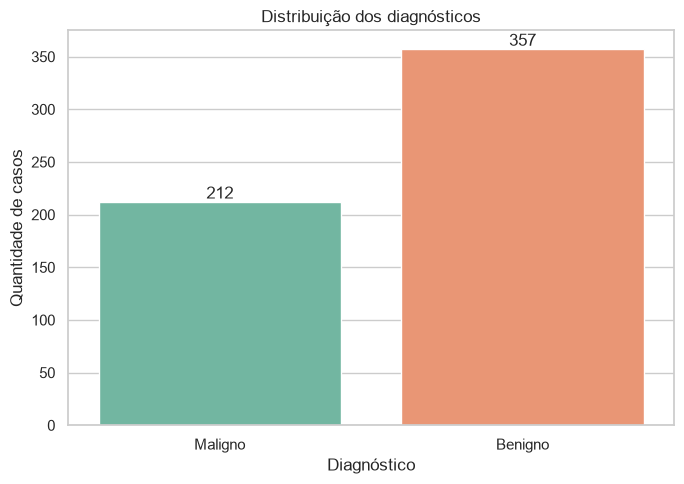

In [5]:
# Traduzindo os rótulos
rotulos_diagnostico = dados["diagnosis"].map({
    "B": "Benigno",
    "M": "Maligno"
})

plt.figure(figsize=(7, 5))

grafico = sns.countplot(
    x=rotulos_diagnostico,
    hue=rotulos_diagnostico,
    palette="Set2",
    legend=False
)

plt.title("Distribuição dos diagnósticos")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade de casos")

# Mostrar os valores sobre as barras
for barra in grafico.patches:

    altura = int(barra.get_height())

    grafico.annotate(
        str(altura),
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
salvar_figura("01_distribuicao_diagnosticos")
plt.show()

In [6]:
# Criando uma cópia para preservar a base original
df = dados.copy()

# Removendo colunas que não contribuem para o modelo
df = df.drop(
    columns=[
        "id",
        "Unnamed: 32"
    ],
    errors="ignore"
)

# Convertendo o diagnóstico
# B = Benigno = 0
# M = Maligno = 1
mapa_diagnostico = {
    "B": 0,
    "M": 1
}

df["diagnosis"] = df["diagnosis"].map(
    mapa_diagnostico
)

# Validando a conversão
if df["diagnosis"].isnull().any():
    raise ValueError(
        "Existem valores inválidos na coluna diagnosis."
    )

df["diagnosis"] = df["diagnosis"].astype(int)

# Removendo duplicados, caso existam
duplicados_antes = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicados_depois = df.duplicated().sum()

print("LIMPEZA CONCLUÍDA")
print("-----------------")
print(f"Dimensões após a limpeza: {df.shape}")
print(f"Duplicados antes: {duplicados_antes}")
print(f"Duplicados depois: {duplicados_depois}")
print(f"Total de valores ausentes: {df.isnull().sum().sum()}")

print("\nDistribuição final do diagnóstico:")
print(df["diagnosis"].value_counts())

print("\n0 = Benigno")
print("1 = Maligno")

LIMPEZA CONCLUÍDA
-----------------
Dimensões após a limpeza: (569, 31)
Duplicados antes: 0
Duplicados depois: 0
Total de valores ausentes: 0

Distribuição final do diagnóstico:
diagnosis
0    357
1    212
Name: count, dtype: int64

0 = Benigno
1 = Maligno


In [7]:
# Estatísticas das variáveis explicativas
estatisticas_descritivas = (
    df.drop(columns=["diagnosis"])
    .describe()
    .T
)

print("ESTATÍSTICAS DESCRITIVAS")
print("-----------------------")

display(estatisticas_descritivas)

# Médias separadas por diagnóstico
medias_por_diagnostico = (
    df.groupby("diagnosis")
    .mean(numeric_only=True)
    .T
)

medias_por_diagnostico.columns = [
    "benigno",
    "maligno"
]

medias_por_diagnostico["diferenca_absoluta"] = (
    medias_por_diagnostico["maligno"]
    - medias_por_diagnostico["benigno"]
).abs()

medias_por_diagnostico = (
    medias_por_diagnostico
    .sort_values(
        "diferenca_absoluta",
        ascending=False
    )
)

print("Maiores diferenças entre as médias:")
display(medias_por_diagnostico.head(10))

ESTATÍSTICAS DESCRITIVAS
-----------------------


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Maiores diferenças entre as médias:


,benigno,maligno,diferenca_absoluta
area_worst,558.899440,1422.286321,863.386881
area_mean,462.790196,978.376415,515.586219
perimeter_worst,87.005938,141.370330,54.364392
area_se,21.135148,72.672406,51.537257
perimeter_mean,78.075406,115.365377,37.289971
radius_worst,13.379801,21.134811,7.755010
texture_worst,23.515070,29.318208,5.803138
radius_mean,12.146524,17.462830,5.316306
texture_mean,17.914762,21.604906,3.690144
perimeter_se,2.000321,4.323929,2.323608


Imagem salva: imagens_resultados\02_distribuicao_variaveis.png


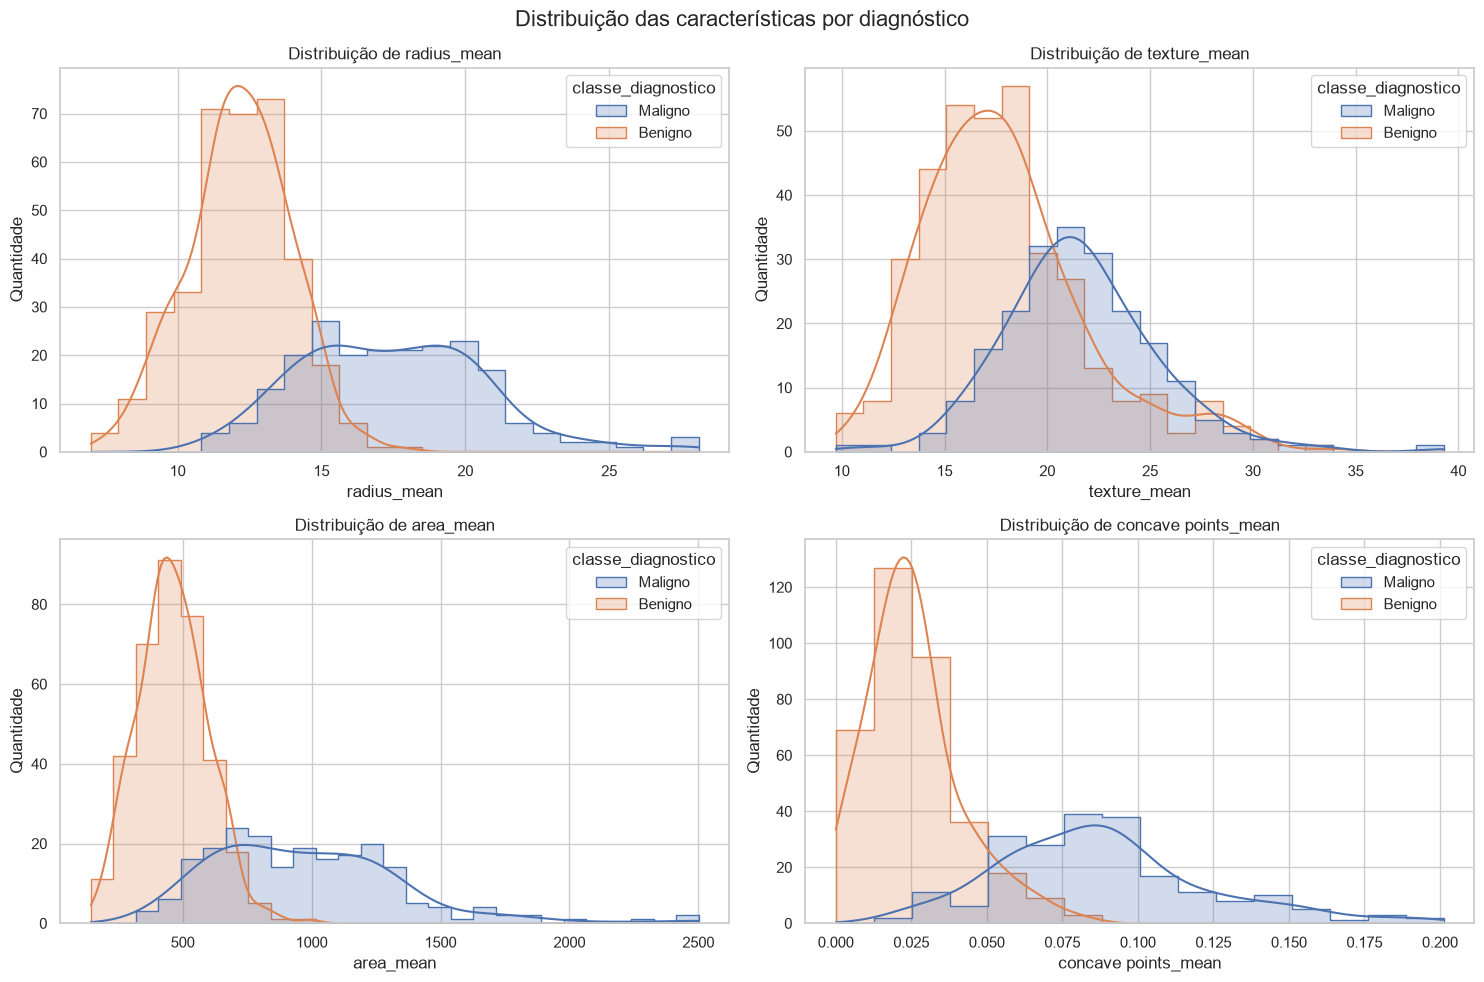

Imagem salva: imagens_resultados\03_boxplots_variaveis.png


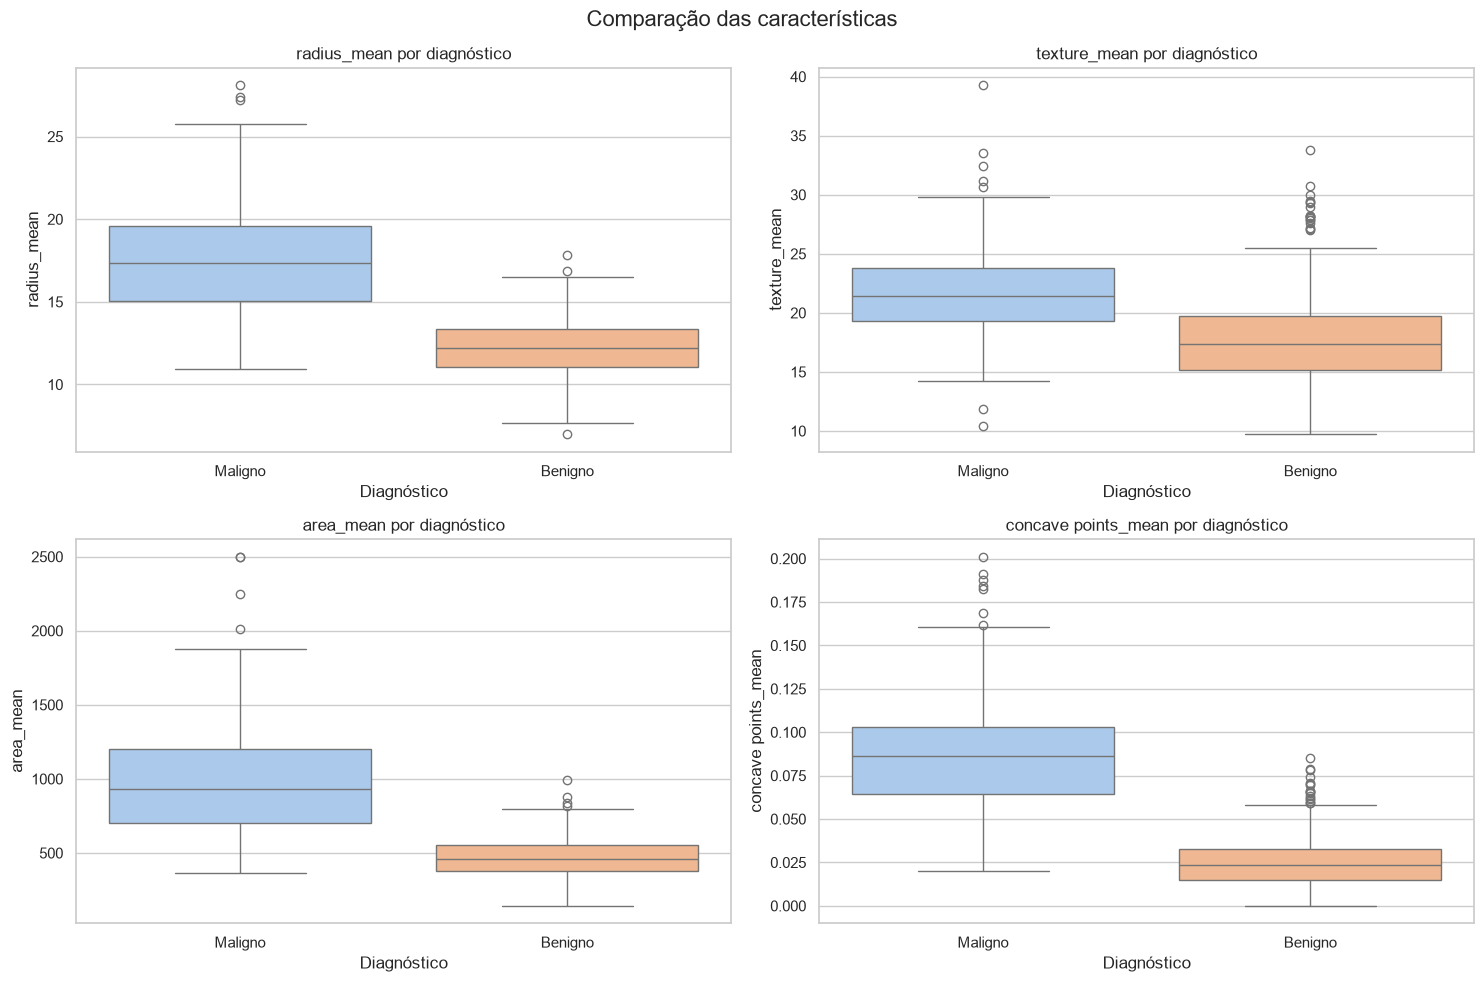

In [8]:
# Variáveis selecionadas para análise visual
variaveis_analisadas = [
    "radius_mean",
    "texture_mean",
    "area_mean",
    "concave points_mean"
]

dados_grafico = df.copy()

dados_grafico["classe_diagnostico"] = (
    dados_grafico["diagnosis"].map({
        0: "Benigno",
        1: "Maligno"
    })
)

# Histogramas
figura, eixos = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

eixos = eixos.flatten()

for eixo, variavel in zip(
    eixos,
    variaveis_analisadas
):

    sns.histplot(
        data=dados_grafico,
        x=variavel,
        hue="classe_diagnostico",
        kde=True,
        element="step",
        common_norm=False,
        ax=eixo
    )

    eixo.set_title(
        f"Distribuição de {variavel}"
    )

    eixo.set_xlabel(variavel)
    eixo.set_ylabel("Quantidade")

plt.suptitle(
    "Distribuição das características por diagnóstico",
    fontsize=16
)

plt.tight_layout()
salvar_figura("02_distribuicao_variaveis")
plt.show()

# Boxplots
figura, eixos = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

eixos = eixos.flatten()

for eixo, variavel in zip(
    eixos,
    variaveis_analisadas
):

    sns.boxplot(
        data=dados_grafico,
        x="classe_diagnostico",
        y=variavel,
        hue="classe_diagnostico",
        palette="pastel",
        legend=False,
        ax=eixo
    )

    eixo.set_title(
        f"{variavel} por diagnóstico"
    )

    eixo.set_xlabel("Diagnóstico")
    eixo.set_ylabel(variavel)

plt.suptitle(
    "Comparação das características",
    fontsize=16
)

plt.tight_layout()
salvar_figura("03_boxplots_variaveis")
plt.show()

Imagem salva: imagens_resultados\04_matriz_correlacao_completa.png


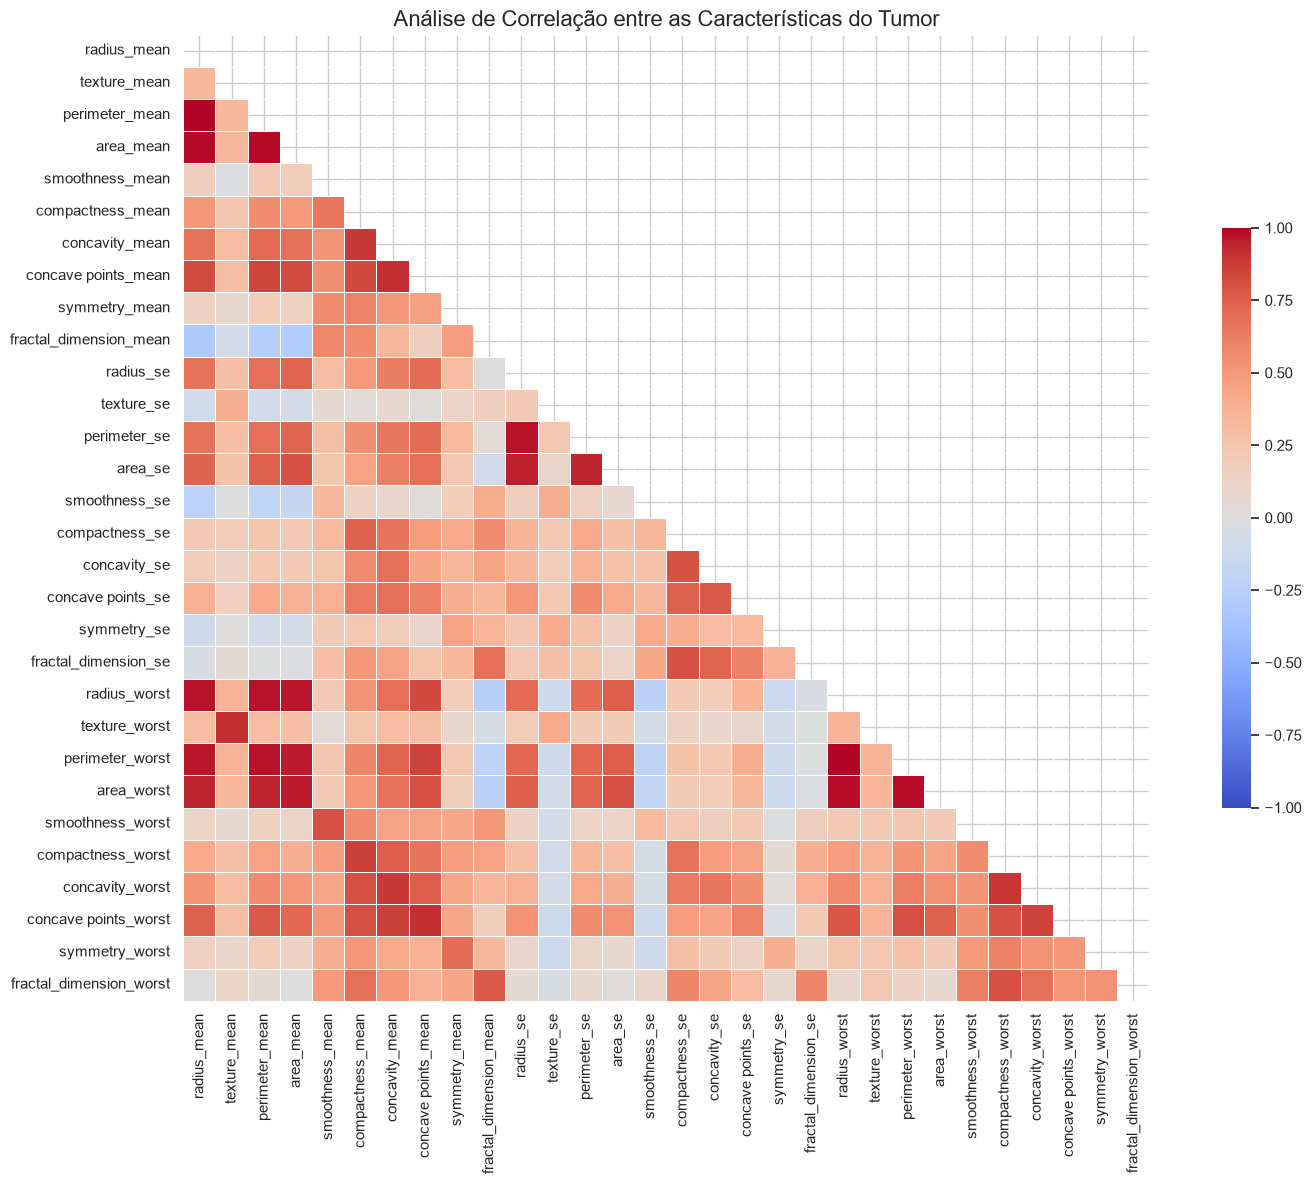

In [9]:
# Matriz completa sem a variável-alvo
matriz_correlacao_completa = (
    df.drop(columns=["diagnosis"])
    .corr(numeric_only=True)
)

# Máscara para ocultar a metade repetida
mascara = np.triu(
    np.ones_like(
        matriz_correlacao_completa,
        dtype=bool
    )
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacao_completa,
    mask=mascara,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.6}
)

plt.title(
    "Análise de Correlação entre as Características do Tumor",
    fontsize=16
)

plt.tight_layout()
salvar_figura("04_matriz_correlacao_completa")
plt.show()

Variáveis mais relacionadas com o diagnóstico:


,correlacao
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


Imagem salva: imagens_resultados\05_principais_correlacoes.png


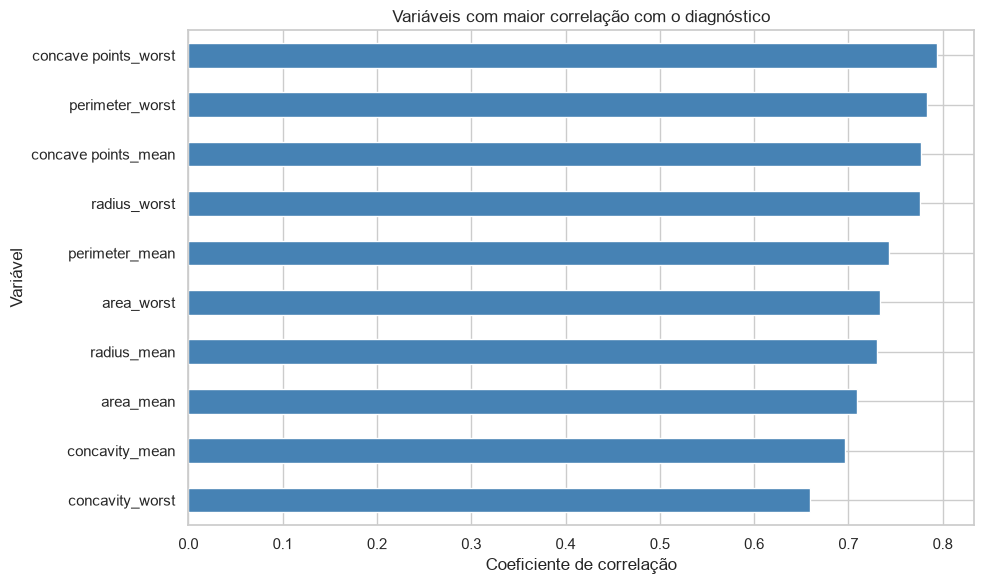

Imagem salva: imagens_resultados\06_matriz_correlacao_principais.png


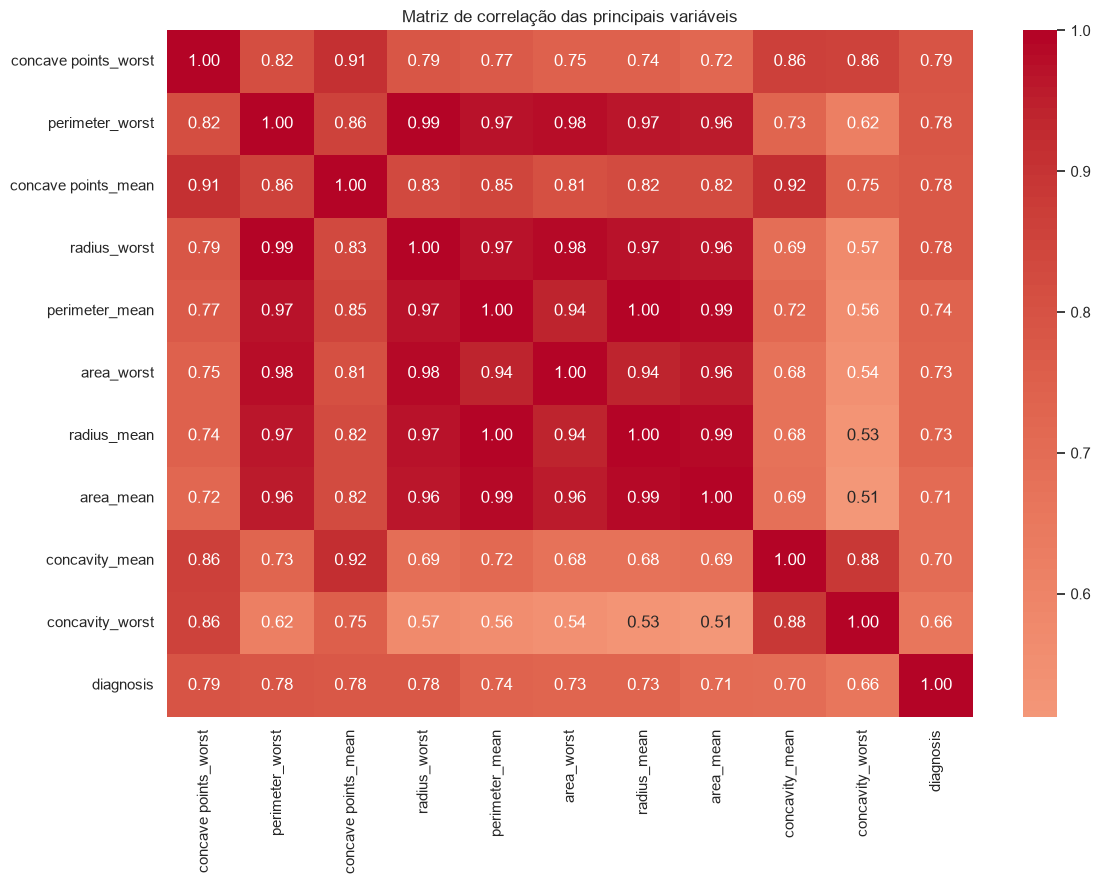

In [10]:
# Correlação das características com o diagnóstico
correlacoes_diagnostico = (
    df.corr(numeric_only=True)["diagnosis"]
    .drop("diagnosis")
    .sort_values(
        key=lambda valores: valores.abs(),
        ascending=False
    )
)

print("Variáveis mais relacionadas com o diagnóstico:")
display(
    correlacoes_diagnostico
    .head(15)
    .to_frame("correlacao")
)

# Gráfico das dez principais correlações
principais_correlacoes = (
    correlacoes_diagnostico
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

principais_correlacoes.plot(
    kind="barh",
    color="steelblue"
)

plt.title(
    "Variáveis com maior correlação com o diagnóstico"
)

plt.xlabel("Coeficiente de correlação")
plt.ylabel("Variável")

plt.tight_layout()
salvar_figura("05_principais_correlacoes")
plt.show()

# Matriz reduzida para facilitar a interpretação
variaveis_principais = (
    correlacoes_diagnostico
    .head(10)
    .index
    .tolist()
)

colunas_matriz_reduzida = (
    variaveis_principais
    + ["diagnosis"]
)

matriz_reduzida = (
    df[colunas_matriz_reduzida]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_reduzida,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Matriz de correlação das principais variáveis"
)

plt.tight_layout()
salvar_figura("06_matriz_correlacao_principais")
plt.show()

In [11]:
# Separação em variáveis explicativas (X) e variável-alvo (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("SEPARAÇÃO TREINO/TESTE")
print("----------------------")
print(f"Registros de treino: {len(X_train)}")
print(f"Registros de teste: {len(X_test)}")

SEPARAÇÃO TREINO/TESTE
----------------------
Registros de treino: 455
Registros de teste: 114


Imagem salva: imagens_resultados\07_antes_depois_padronizacao.png


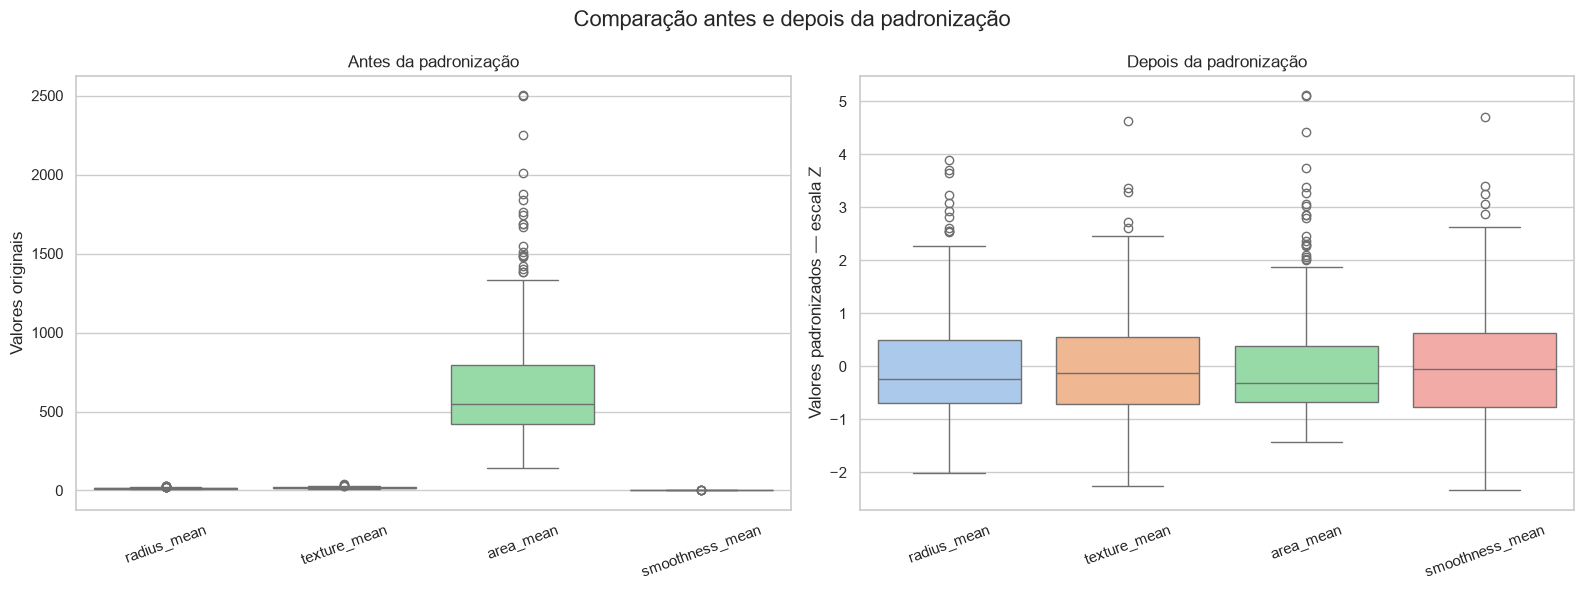

In [12]:
# Comparação visual utilizada no código inicial do grupo
colunas_exemplo = [
    "radius_mean",
    "texture_mean",
    "area_mean",
    "smoothness_mean"
]

# O scaler visual aprende somente com o treino
scaler_visual = StandardScaler()

dados_antes = X_train[
    colunas_exemplo
].copy()

dados_depois = pd.DataFrame(
    scaler_visual.fit_transform(dados_antes),
    columns=colunas_exemplo,
    index=dados_antes.index
)

figura, eixos = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.boxplot(
    data=dados_antes,
    palette="pastel",
    ax=eixos[0]
)

eixos[0].set_title(
    "Antes da padronização"
)

eixos[0].set_ylabel(
    "Valores originais"
)

eixos[0].tick_params(
    axis="x",
    rotation=20
)

sns.boxplot(
    data=dados_depois,
    palette="pastel",
    ax=eixos[1]
)

eixos[1].set_title(
    "Depois da padronização"
)

eixos[1].set_ylabel(
    "Valores padronizados — escala Z"
)

eixos[1].tick_params(
    axis="x",
    rotation=20
)

plt.suptitle(
    "Comparação antes e depois da padronização",
    fontsize=16
)

plt.tight_layout()
salvar_figura("07_antes_depois_padronizacao")
plt.show()

In [13]:
# Os modelos lineares e de distância usam StandardScaler
# dentro do Pipeline para evitar vazamento de dados.

modelos = {
    "Regressão Logística": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ]),

    "KNN": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]),

    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    # Random Forest original do código do grupo
    "Random Forest": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])
}

print("MODELOS CRIADOS")
print("---------------")

for nome_modelo in modelos:
    print(f"- {nome_modelo}")

MODELOS CRIADOS
---------------
- Regressão Logística
- KNN
- Árvore de Decisão
- Random Forest


In [14]:
modelos_treinados = {}
previsoes_modelos = {}
probabilidades_modelos = {}
resultados_avaliacao = []

for nome_modelo, modelo in modelos.items():

    # Treinamento
    modelo.fit(
        X_train,
        y_train
    )

    # Previsões
    previsoes = modelo.predict(
        X_test
    )

    probabilidades = modelo.predict_proba(
        X_test
    )[:, 1]

    # Armazenamento
    modelos_treinados[nome_modelo] = modelo
    previsoes_modelos[nome_modelo] = previsoes
    probabilidades_modelos[nome_modelo] = probabilidades

    # Métricas
    resultados_avaliacao.append({
        "modelo": nome_modelo,

        "accuracy": accuracy_score(
            y_test,
            previsoes
        ),

        "precision": precision_score(
            y_test,
            previsoes,
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            previsoes,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_test,
            previsoes,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_test,
            probabilidades
        )
    })

# Criando a tabela
tabela_resultados = pd.DataFrame(
    resultados_avaliacao
)

tabela_resultados = (
    tabela_resultados
    .sort_values(
        by=[
            "recall",
            "f1_score",
            "roc_auc"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("RESULTADOS DO CONJUNTO DE TESTE")
print("--------------------------------")

display(tabela_resultados.round(4))

tabela_resultados.to_csv(
    PASTA_IMAGENS / "tabela_metricas_teste.csv",
    index=False
)

RESULTADOS DO CONJUNTO DE TESTE
--------------------------------


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
1,Regressão Logística,0.9649,0.9750,0.9286,0.9512,0.9960
2,KNN,0.9561,0.9744,0.9048,0.9383,0.9823
3,Árvore de Decisão,0.9211,0.9459,0.8333,0.8861,0.9448


Imagem salva: imagens_resultados\08_comparacao_metricas_modelos.png


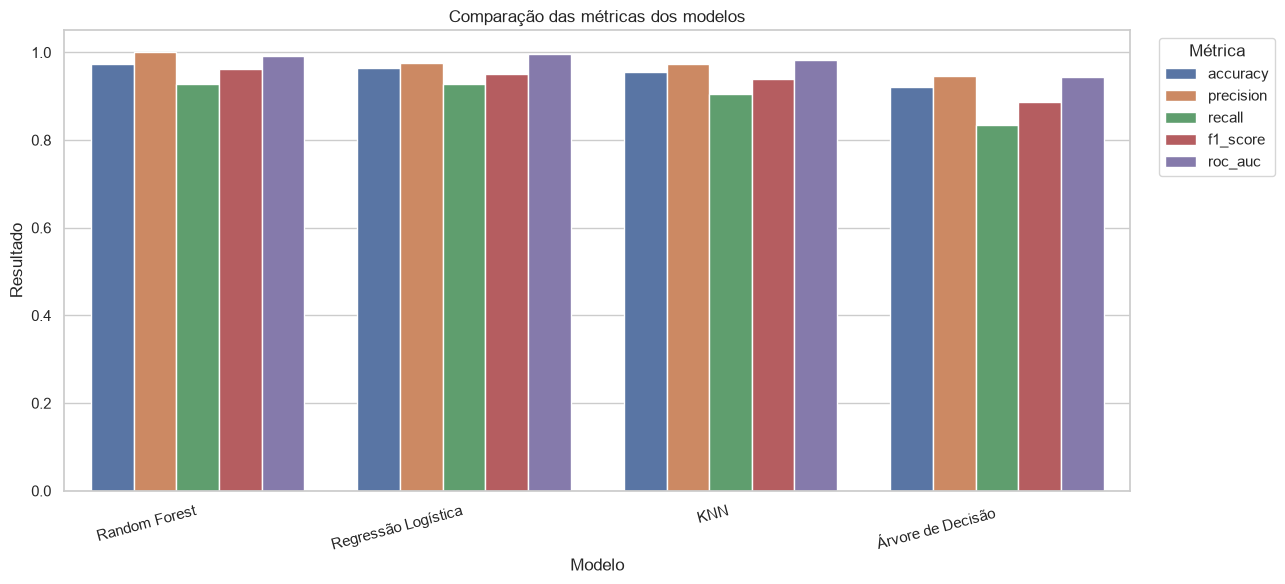

In [15]:
resultados_grafico = tabela_resultados.melt(
    id_vars="modelo",
    value_vars=[
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=resultados_grafico,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title(
    "Comparação das métricas dos modelos"
)

plt.xlabel("Modelo")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
salvar_figura("08_comparacao_metricas_modelos")
plt.show()

Imagem salva: imagens_resultados\09_matrizes_confusao_modelos.png


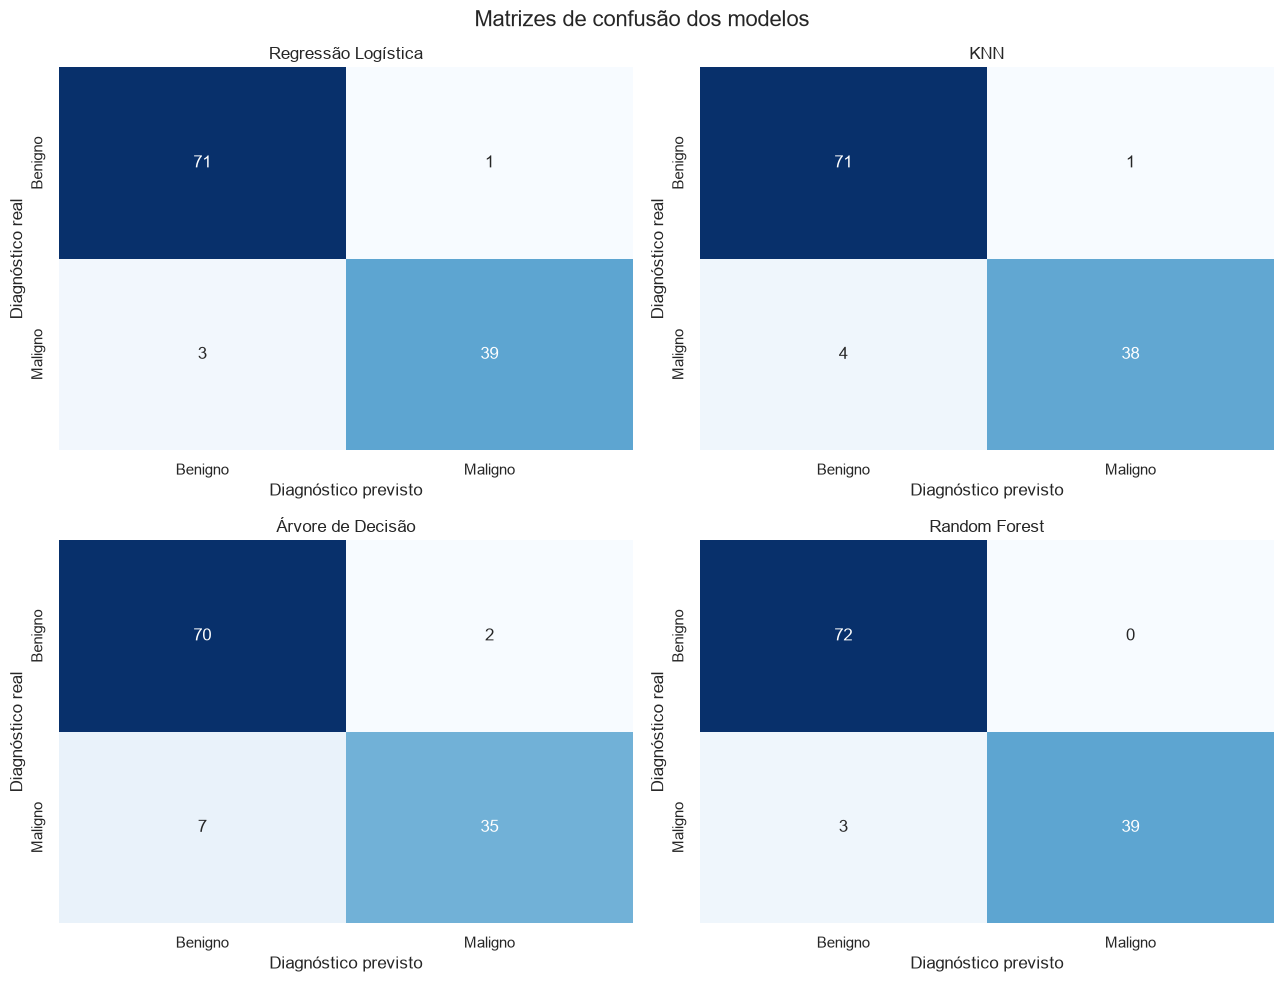


Regressão Logística
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


KNN
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97        72
     Maligno       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Árvore de Decisão
              precision    recall  f1-score   support

     Benigno       0.91      0.97      0.94        72
     Maligno       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      

In [16]:
figura, eixos = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

eixos = eixos.flatten()

for eixo, (
    nome_modelo,
    previsoes
) in zip(
    eixos,
    previsoes_modelos.items()
):

    matriz = confusion_matrix(
        y_test,
        previsoes
    )

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[
            "Benigno",
            "Maligno"
        ],
        yticklabels=[
            "Benigno",
            "Maligno"
        ],
        ax=eixo
    )

    eixo.set_title(nome_modelo)
    eixo.set_xlabel("Diagnóstico previsto")
    eixo.set_ylabel("Diagnóstico real")

plt.suptitle(
    "Matrizes de confusão dos modelos",
    fontsize=16
)

plt.tight_layout()
salvar_figura("09_matrizes_confusao_modelos")
plt.show()

# Relatórios detalhados
for nome_modelo, previsoes in previsoes_modelos.items():

    print("\n" + "=" * 60)
    print(nome_modelo)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            previsoes,
            target_names=[
                "Benigno",
                "Maligno"
            ],
            zero_division=0
        )
    )

Imagem salva: imagens_resultados\10_curvas_roc_modelos.png


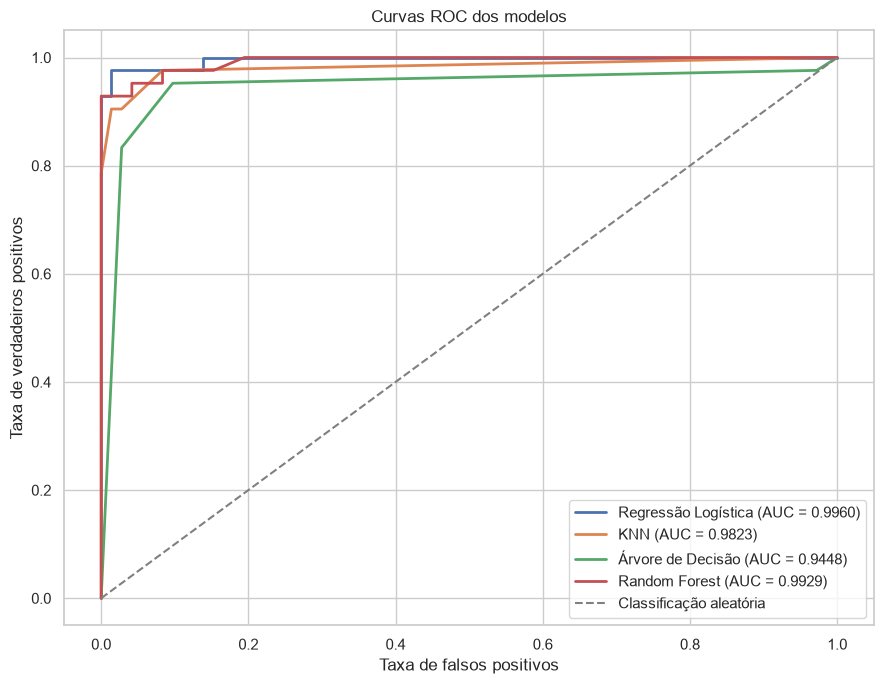

In [17]:
plt.figure(figsize=(9, 7))

for nome_modelo, probabilidades in (
    probabilidades_modelos.items()
):

    fpr, tpr, limites = roc_curve(
        y_test,
        probabilidades
    )

    auc_modelo = roc_auc_score(
        y_test,
        probabilidades
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{nome_modelo} "
            f"(AUC = {auc_modelo:.4f})"
        )
    )

# Linha de referência aleatória
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificação aleatória"
)

plt.title("Curvas ROC dos modelos")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")

plt.legend(loc="lower right")
plt.tight_layout()

salvar_figura("10_curvas_roc_modelos")
plt.show()

In [18]:
# Validação estratificada com cinco divisões
validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_validacao = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1_score": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc"
}

resultados_validacao = []

for nome_modelo, modelo in modelos.items():

    resultado_cv = cross_validate(
        estimator=modelo,
        X=X_train,
        y=y_train,
        cv=validacao_cruzada,
        scoring=metricas_validacao,
        n_jobs=1
    )

    resultados_validacao.append({
        "modelo": nome_modelo,

        "accuracy_media": (
            resultado_cv[
                "test_accuracy"
            ].mean()
        ),

        "precision_media": (
            resultado_cv[
                "test_precision"
            ].mean()
        ),

        "recall_media": (
            resultado_cv[
                "test_recall"
            ].mean()
        ),

        "f1_score_medio": (
            resultado_cv[
                "test_f1_score"
            ].mean()
        ),

        "roc_auc_medio": (
            resultado_cv[
                "test_roc_auc"
            ].mean()
        ),

        "desvio_recall": (
            resultado_cv[
                "test_recall"
            ].std()
        )
    })

    print(
        f"Validação concluída: {nome_modelo}"
    )

tabela_validacao = pd.DataFrame(
    resultados_validacao
)

tabela_validacao = (
    tabela_validacao
    .sort_values(
        by=[
            "recall_media",
            "f1_score_medio",
            "roc_auc_medio"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nRESULTADOS DA VALIDAÇÃO CRUZADA")
print("--------------------------------")

display(tabela_validacao.round(4))

tabela_validacao.to_csv(
    PASTA_IMAGENS / "tabela_validacao_cruzada.csv",
    index=False
)

Validação concluída: Regressão Logística
Validação concluída: KNN
Validação concluída: Árvore de Decisão
Validação concluída: Random Forest

RESULTADOS DA VALIDAÇÃO CRUZADA
--------------------------------


,modelo,accuracy_media,precision_media,recall_media,f1_score_medio,roc_auc_medio,desvio_recall
0,Regressão Logística,0.9736,0.9771,0.9529,0.9640,0.9958,0.0399
1,Random Forest,0.9648,0.9641,0.9412,0.9519,0.9889,0.0416
2,KNN,0.9648,0.9875,0.9176,0.9510,0.9871,0.0343
3,Árvore de Decisão,0.9077,0.8943,0.8529,0.8717,0.8875,0.0852


Imagem salva: imagens_resultados\11_recall_validacao_cruzada.png


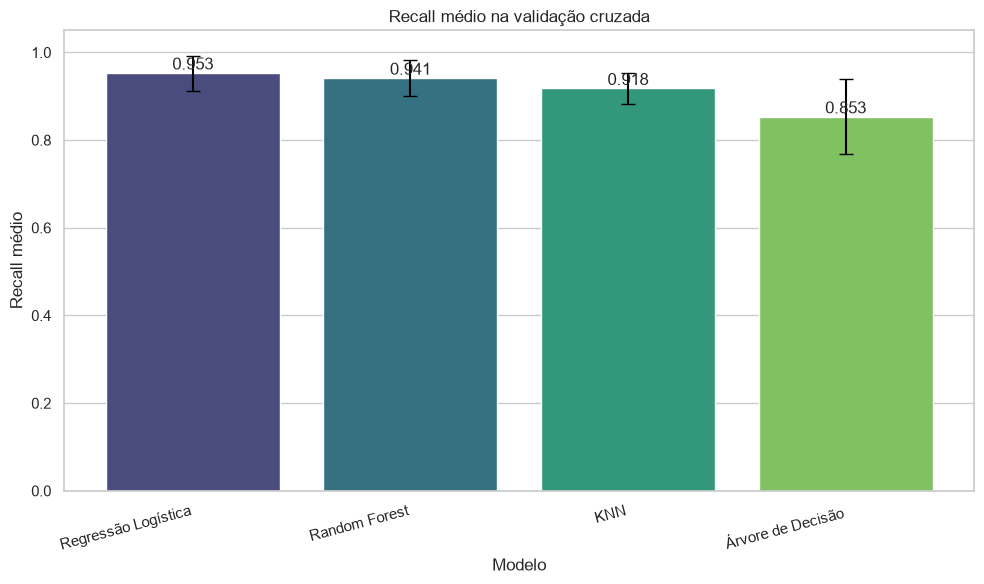

In [19]:
plt.figure(figsize=(10, 6))

grafico = sns.barplot(
    data=tabela_validacao,
    x="modelo",
    y="recall_media",
    hue="modelo",
    palette="viridis",
    legend=False
)

plt.errorbar(
    x=range(len(tabela_validacao)),
    y=tabela_validacao["recall_media"],
    yerr=tabela_validacao["desvio_recall"],
    fmt="none",
    color="black",
    capsize=5
)

plt.title(
    "Recall médio na validação cruzada"
)

plt.xlabel("Modelo")
plt.ylabel("Recall médio")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=15,
    ha="right"
)

for barra in grafico.patches:

    valor = barra.get_height()

    grafico.annotate(
        f"{valor:.3f}",
        (
            barra.get_x()
            + barra.get_width() / 2,
            valor
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
salvar_figura("11_recall_validacao_cruzada")
plt.show()

In [20]:
comparacao_modelos = pd.merge(
    tabela_resultados,
    tabela_validacao,
    on="modelo",
    how="inner"
)

comparacao_modelos["diferenca_recall"] = (
    comparacao_modelos["recall"]
    - comparacao_modelos["recall_media"]
).abs()

comparacao_modelos = (
    comparacao_modelos
    .sort_values(
        by=[
            "recall_media",
            "f1_score_medio",
            "roc_auc_medio",
            "desvio_recall"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

print("COMPARAÇÃO ENTRE TESTE E VALIDAÇÃO")
print("----------------------------------")

display(comparacao_modelos.round(4))

# Selecionar o candidato usando a validação cruzada
modelo_candidato_nome = (
    comparacao_modelos.iloc[0]["modelo"]
)

modelo_candidato = modelos[
    modelo_candidato_nome
]

print("\nMODELO CANDIDATO")
print("----------------")
print(f"Modelo: {modelo_candidato_nome}")
print(
    f"Recall médio: "
    f"{comparacao_modelos.iloc[0]['recall_media']:.4f}"
)
print(
    f"Desvio do recall: "
    f"{comparacao_modelos.iloc[0]['desvio_recall']:.4f}"
)

comparacao_modelos.to_csv(
    PASTA_IMAGENS / "comparacao_teste_validacao.csv",
    index=False
)

COMPARAÇÃO ENTRE TESTE E VALIDAÇÃO
----------------------------------


,modelo,accuracy,precision,recall,f1_score,roc_auc,accuracy_media,precision_media,recall_media,f1_score_medio,roc_auc_medio,desvio_recall,diferenca_recall
0,Regressão Logística,0.9649,0.9750,0.9286,0.9512,0.9960,0.9736,0.9771,0.9529,0.9640,0.9958,0.0399,0.0244
1,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929,0.9648,0.9641,0.9412,0.9519,0.9889,0.0416,0.0126
2,KNN,0.9561,0.9744,0.9048,0.9383,0.9823,0.9648,0.9875,0.9176,0.9510,0.9871,0.0343,0.0129
3,Árvore de Decisão,0.9211,0.9459,0.8333,0.8861,0.9448,0.9077,0.8943,0.8529,0.8717,0.8875,0.0852,0.0196



MODELO CANDIDATO
----------------
Modelo: Regressão Logística
Recall médio: 0.9529
Desvio do recall: 0.0399


In [21]:
# Grades disponíveis para cada possível candidato
grades_parametros = {
    "Regressão Logística": {
        "modelo__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],
        "modelo__class_weight": [
            None,
            "balanced"
        ]
    },

    "KNN": {
        "modelo__n_neighbors": [
            3,
            5,
            7,
            9,
            11
        ],
        "modelo__weights": [
            "uniform",
            "distance"
        ],
        "modelo__p": [
            1,
            2
        ]
    },

    "Árvore de Decisão": {
        "max_depth": [
            None,
            3,
            5,
            7,
            10
        ],
        "min_samples_split": [
            2,
            5,
            10
        ],
        "min_samples_leaf": [
            1,
            2,
            4
        ],
        "class_weight": [
            None,
            "balanced"
        ]
    },

    "Random Forest": {
        "modelo__n_estimators": [
            100,
            200,
            300
        ],
        "modelo__max_depth": [
            None,
            5,
            10
        ],
        "modelo__min_samples_split": [
            2,
            5
        ],
        "modelo__min_samples_leaf": [
            1,
            2
        ],
        "modelo__class_weight": [
            None,
            "balanced"
        ]
    }
}

parametros_candidato = grades_parametros[
    modelo_candidato_nome
]

busca_hiperparametros = GridSearchCV(
    estimator=modelo_candidato,
    param_grid=parametros_candidato,
    scoring="recall",
    cv=validacao_cruzada,
    n_jobs=1,
    refit=True
)

busca_hiperparametros.fit(
    X_train,
    y_train
)

print("OTIMIZAÇÃO CONCLUÍDA")
print("--------------------")

print(
    f"Modelo: {modelo_candidato_nome}"
)

print(
    f"Melhor recall médio: "
    f"{busca_hiperparametros.best_score_:.4f}"
)

print("\nMelhores hiperparâmetros:")

for parametro, valor in (
    busca_hiperparametros
    .best_params_
    .items()
):
    print(f"- {parametro}: {valor}")

modelo_final = (
    busca_hiperparametros
    .best_estimator_
)

OTIMIZAÇÃO CONCLUÍDA
--------------------
Modelo: Regressão Logística
Melhor recall médio: 0.9588

Melhores hiperparâmetros:
- modelo__C: 1
- modelo__class_weight: balanced


In [22]:
# Previsões finais
previsoes_finais = modelo_final.predict(
    X_test
)

probabilidades_finais = (
    modelo_final
    .predict_proba(X_test)[:, 1]
)

# Métricas finais
accuracy_final = accuracy_score(
    y_test,
    previsoes_finais
)

precision_final = precision_score(
    y_test,
    previsoes_finais,
    zero_division=0
)

recall_final = recall_score(
    y_test,
    previsoes_finais,
    zero_division=0
)

f1_final = f1_score(
    y_test,
    previsoes_finais,
    zero_division=0
)

roc_auc_final = roc_auc_score(
    y_test,
    probabilidades_finais
)

resultado_final = pd.DataFrame({
    "modelo": [
        modelo_candidato_nome
    ],
    "accuracy": [
        accuracy_final
    ],
    "precision": [
        precision_final
    ],
    "recall": [
        recall_final
    ],
    "f1_score": [
        f1_final
    ],
    "roc_auc": [
        roc_auc_final
    ]
})

print("RESULTADO DO MODELO FINAL")
print("-------------------------")

display(resultado_final.round(4))

print(
    classification_report(
        y_test,
        previsoes_finais,
        target_names=[
            "Benigno",
            "Maligno"
        ],
        zero_division=0
    )
)

RESULTADO DO MODELO FINAL
-------------------------


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regressão Logística,0.9737,0.9756,0.9524,0.9639,0.9954


              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



COMPARAÇÃO DA OTIMIZAÇÃO
------------------------


,modelo,accuracy,precision,recall,f1_score,roc_auc,versao
0,Regressão Logística,0.9649,0.9750,0.9286,0.9512,0.9960,Original
1,Regressão Logística,0.9737,0.9756,0.9524,0.9639,0.9954,Otimizado


Imagem salva: imagens_resultados\12_original_vs_otimizado.png


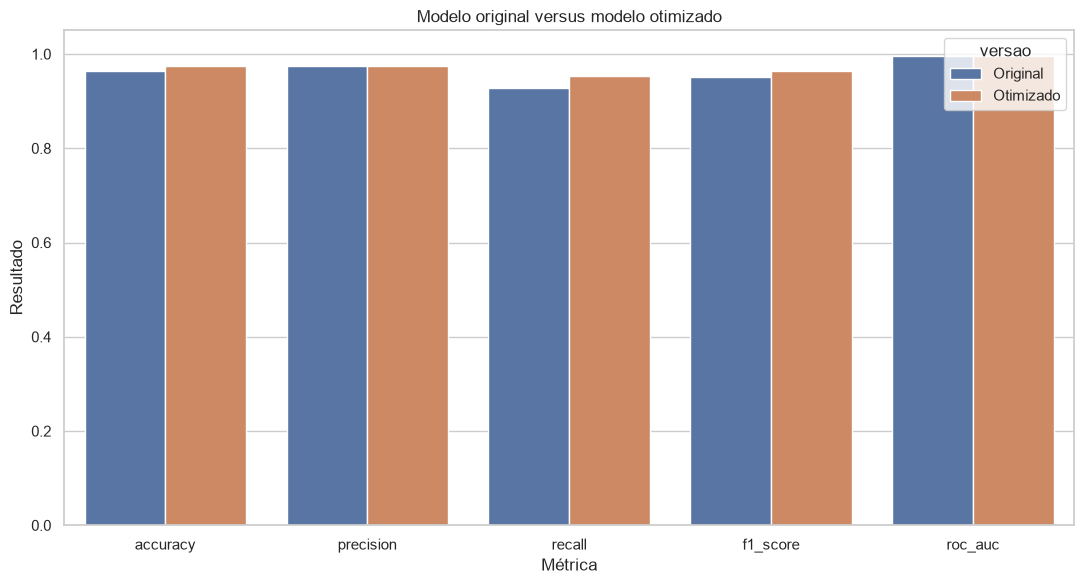

In [23]:
resultado_original = (
    tabela_resultados[
        tabela_resultados["modelo"]
        == modelo_candidato_nome
    ]
    .copy()
)

resultado_original["versao"] = "Original"

resultado_otimizado = resultado_final.copy()
resultado_otimizado["versao"] = "Otimizado"

comparacao_otimizacao = pd.concat(
    [
        resultado_original,
        resultado_otimizado
    ],
    ignore_index=True
)

print("COMPARAÇÃO DA OTIMIZAÇÃO")
print("------------------------")

display(comparacao_otimizacao.round(4))

dados_comparacao = (
    comparacao_otimizacao
    .melt(
        id_vars=[
            "versao",
            "modelo"
        ],
        value_vars=[
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc"
        ],
        var_name="metrica",
        value_name="valor"
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=dados_comparacao,
    x="metrica",
    y="valor",
    hue="versao"
)

plt.title(
    "Modelo original versus modelo otimizado"
)

plt.xlabel("Métrica")
plt.ylabel("Resultado")
plt.ylim(0, 1.05)

plt.tight_layout()
salvar_figura("12_original_vs_otimizado")
plt.show()

Imagem salva: imagens_resultados\13_matriz_confusao_modelo_final.png


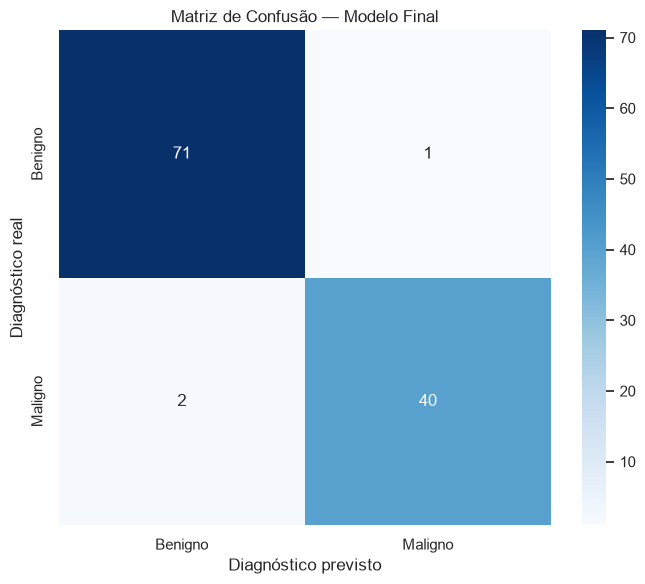

Matriz final:
[[71  1]
 [ 2 40]]


In [24]:
matriz_final = confusion_matrix(
    y_test,
    previsoes_finais
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benigno",
        "Maligno"
    ],
    yticklabels=[
        "Benigno",
        "Maligno"
    ]
)

plt.title(
    "Matriz de Confusão — Modelo Final"
)

plt.xlabel("Diagnóstico previsto")
plt.ylabel("Diagnóstico real")

plt.tight_layout()
salvar_figura("13_matriz_confusao_modelo_final")
plt.show()

print("Matriz final:")
print(matriz_final)

IMPORTÂNCIA POR PERMUTAÇÃO
--------------------------


,variavel,importancia_media,desvio_padrao
0,texture_worst,0.0603,0.0273
1,concavity_worst,0.0452,0.0263
2,symmetry_worst,0.0381,0.0200
3,concave points_worst,0.0365,0.0211
4,concave points_mean,0.0198,0.0185
5,radius_worst,0.0183,0.0201
6,texture_se,0.0175,0.0122
7,perimeter_worst,0.0167,0.0176
8,concavity_mean,0.0151,0.0144
9,area_worst,0.0151,0.0189


Imagem salva: imagens_resultados\14_importancia_permutacao.png


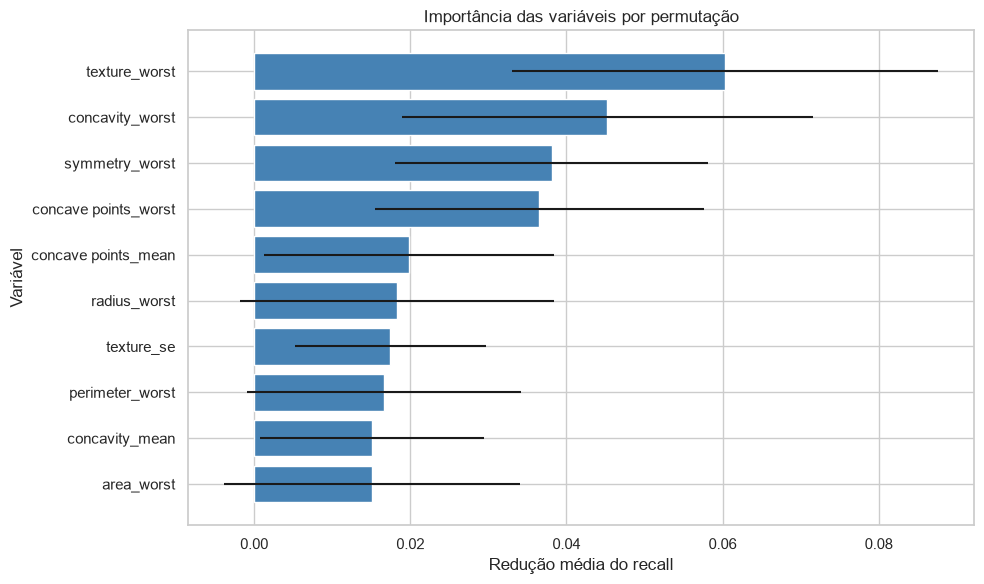

In [25]:
resultado_importancia = permutation_importance(
    estimator=modelo_final,
    X=X_test,
    y=y_test,
    scoring="recall",
    n_repeats=30,
    random_state=42,
    n_jobs=1
)

tabela_importancia = pd.DataFrame({
    "variavel": X_test.columns,
    "importancia_media": (
        resultado_importancia
        .importances_mean
    ),
    "desvio_padrao": (
        resultado_importancia
        .importances_std
    )
})

tabela_importancia = (
    tabela_importancia
    .sort_values(
        "importancia_media",
        ascending=False
    )
    .reset_index(drop=True)
)

print("IMPORTÂNCIA POR PERMUTAÇÃO")
print("--------------------------")

display(tabela_importancia.head(15).round(4))

principais_importancias = (
    tabela_importancia
    .head(10)
    .sort_values(
        "importancia_media",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    principais_importancias["variavel"],
    principais_importancias["importancia_media"],
    xerr=principais_importancias["desvio_padrao"],
    color="steelblue"
)

plt.title(
    "Importância das variáveis por permutação"
)

plt.xlabel("Redução média do recall")
plt.ylabel("Variável")

plt.tight_layout()
salvar_figura("14_importancia_permutacao")
plt.show()

tabela_importancia.to_csv(
    PASTA_IMAGENS / "tabela_importancia_permutacao.csv",
    index=False
)

Registros de referência: 50
Registros explicados: 25


C:\Users\ferpo\AppData\Local\Temp\ipykernel_31496\2326341397.py:54: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap, dados_explicacao, plot_type="bar", show=False)


Imagem salva: imagens_resultados\15_shap_importancia_global.png


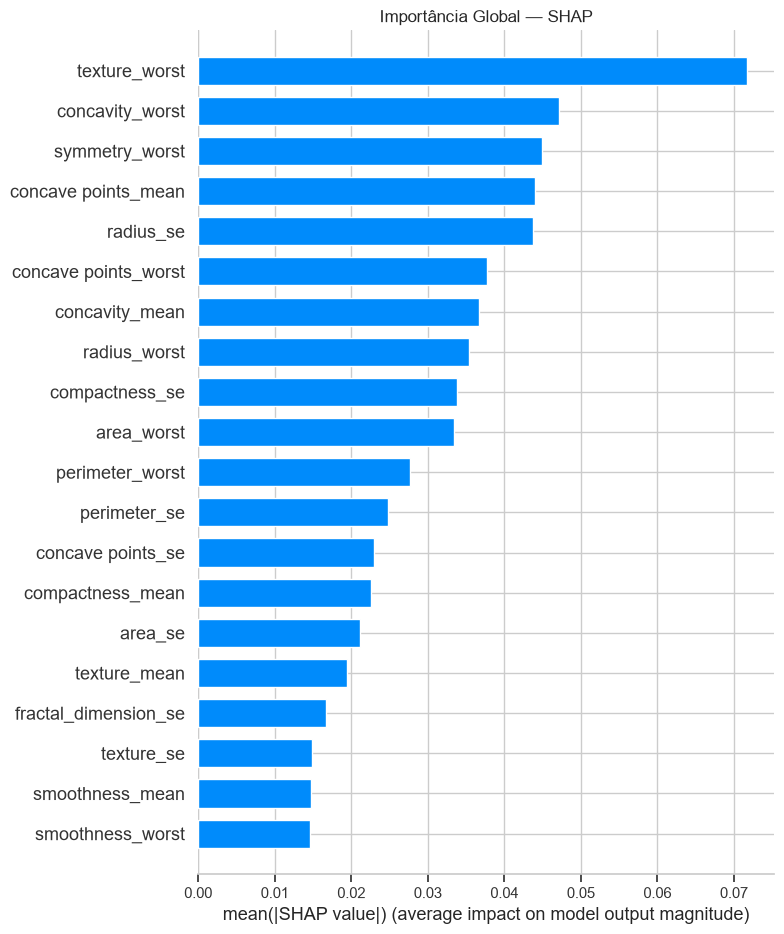

C:\Users\ferpo\AppData\Local\Temp\ipykernel_31496\2326341397.py:61: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap, dados_explicacao, show=False)


Imagem salva: imagens_resultados\16_shap_beeswarm.png


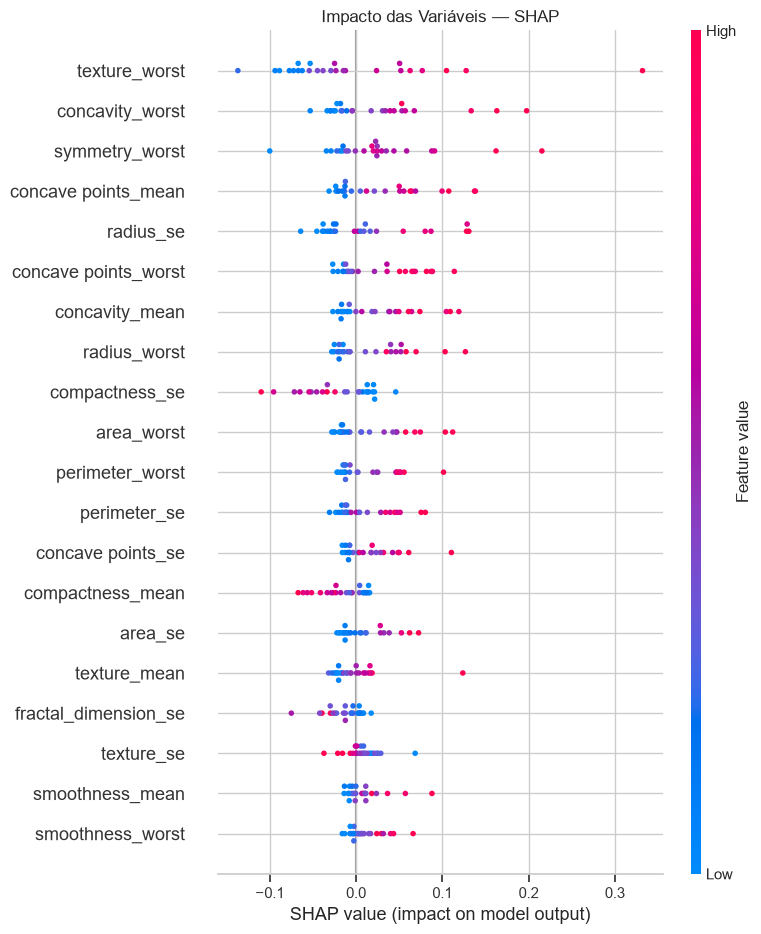

In [26]:
# Amostra de referência para reduzir o tempo do SHAP
quantidade_referencia = min(
    50,
    len(X_train)
)
dados_referencia = X_train.sample(
    n=quantidade_referencia,
    random_state=42
)
# Casos que serão explicados
quantidade_explicacao = min(
    25,
    len(X_test)
)
dados_explicacao = X_test.sample(
    n=quantidade_explicacao,
    random_state=42
)
def prever_probabilidade_maligno(
    dados_entrada
):
    """
    Retorna a probabilidade prevista
    para a classe maligna.
    """
    if isinstance(
        dados_entrada,
        pd.DataFrame
    ):
        dados_entrada_df = (
            dados_entrada.copy()
        )
    else:
        dados_entrada_df = pd.DataFrame(
            dados_entrada,
            columns=X_train.columns
        )
    return modelo_final.predict_proba(
        dados_entrada_df
    )[:, 1]
print(
    f"Registros de referência: "
    f"{len(dados_referencia)}"
)
print(
    f"Registros explicados: "
    f"{len(dados_explicacao)}"
)
# Criando o explainer e calculando os valores SHAP
explainer = shap.Explainer(prever_probabilidade_maligno, dados_referencia)
valores_shap = explainer(dados_explicacao)
# 15 — Importância Global (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, dados_explicacao, plot_type="bar", show=False)
plt.title("Importância Global — SHAP")
plt.tight_layout()
salvar_figura("15_shap_importancia_global")
plt.show()
# 16 — Beeswarm (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, dados_explicacao, show=False)
plt.title("Impacto das Variáveis — SHAP")
plt.tight_layout()
salvar_figura("16_shap_beeswarm")
plt.show()

CASO SELECIONADO
----------------
Índice: 177
Diagnóstico real: 1
Diagnóstico previsto: 1
Probabilidade de malignidade: 0.9921
Imagem salva: imagens_resultados\17_shap_waterfall_individual.png


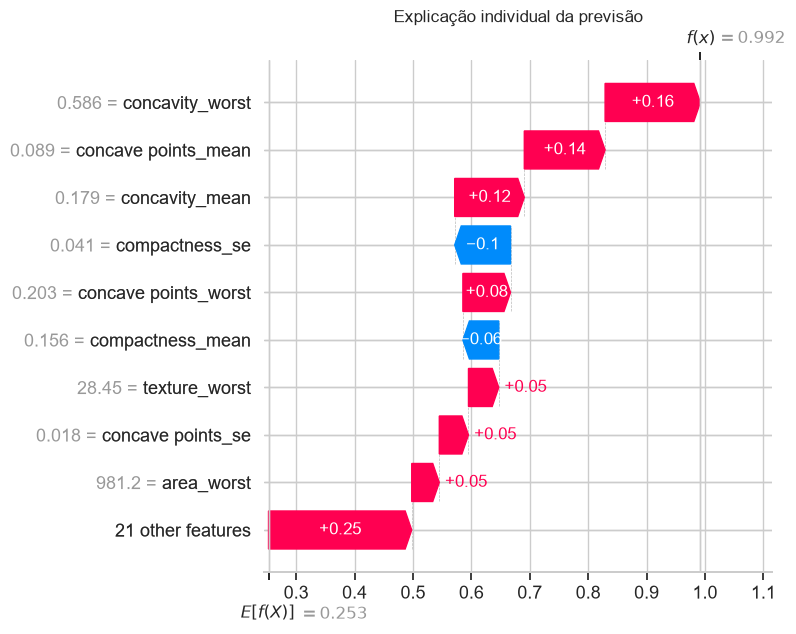

In [27]:
# Procurar um caso realmente maligno
posicoes_malignas = [
    posicao
    for posicao, indice in enumerate(
        dados_explicacao.index
    )
    if y_test.loc[indice] == 1
]

if posicoes_malignas:
    posicao_caso = posicoes_malignas[0]
else:
    posicao_caso = 0

indice_caso = (
    dados_explicacao
    .index[posicao_caso]
)

diagnostico_real = int(
    y_test.loc[indice_caso]
)

probabilidade_maligno = float(
    prever_probabilidade_maligno(
        dados_explicacao.iloc[
            [posicao_caso]
        ]
    )[0]
)

diagnostico_previsto = int(
    probabilidade_maligno >= 0.50
)

print("CASO SELECIONADO")
print("----------------")
print(f"Índice: {indice_caso}")
print(f"Diagnóstico real: {diagnostico_real}")
print(f"Diagnóstico previsto: {diagnostico_previsto}")
print(
    f"Probabilidade de malignidade: "
    f"{probabilidade_maligno:.4f}"
)

shap.plots.waterfall(
    valores_shap[posicao_caso],
    max_display=10,
    show=False
)

plt.title(
    "Explicação individual da previsão"
)

plt.tight_layout()
salvar_figura("17_shap_waterfall_individual")
plt.show()

In [28]:
print("RESUMO DO MODELO FINAL")
print("----------------------")

print(
    f"Modelo: "
    f"{modelo_candidato_nome}"
)

print(
    f"Accuracy: "
    f"{accuracy_final:.4f}"
)

print(
    f"Precision: "
    f"{precision_final:.4f}"
)

print(
    f"Recall: "
    f"{recall_final:.4f}"
)

print(
    f"F1-score: "
    f"{f1_final:.4f}"
)

print(
    f"ROC-AUC: "
    f"{roc_auc_final:.4f}"
)

print("\nMatriz de confusão:")
print(matriz_final)

print(
    "\nEste modelo é experimental e não deve "
    "substituir a avaliação de profissionais "
    "da saúde."
)

RESUMO DO MODELO FINAL
----------------------
Modelo: Regressão Logística
Accuracy: 0.9737
Precision: 0.9756
Recall: 0.9524
F1-score: 0.9639
ROC-AUC: 0.9954

Matriz de confusão:
[[71  1]
 [ 2 40]]

Este modelo é experimental e não deve substituir a avaliação de profissionais da saúde.
